## Importaciones

In [36]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. DEFINICIÓN DE BUCKETS Y TICKERS


In [58]:
# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

bancos = ["GGAL", "BMA", "BBAR"] # Galicia, Macro, BBVA
energia = ["YPF", "TGS", "EDN", "PAM"] # YPF, Transportadora de Gas del Sur, Edenor, Pampa Energía

# Tickers combinados
tickers = bancos + energia

# Definición del rango temporal (acorde al split train/val/test sugerido)
start_date = "2010-01-01"
end_date = "2025-12-31"

print("Descargando datos desde Yahoo Finance...")
df_raw = yf.download(tickers, start=start_date, end=end_date)

# Nos quedamos con los precios de cierre ajustados (Adj Close)
df_prices = df_raw["Close"].copy()
df_prices.head(10)

[                       0%                       ]

Descargando datos desde Yahoo Finance...


[*********************100%***********************]  7 of 7 completed


Ticker,BBAR,BMA,EDN,GGAL,PAM,TGS,YPF
Date,,,,,,,
2010-01-04,3.374005,17.192682,8.20,4.194057,11.756643,1.406721,35.911709
2010-01-05,3.642637,17.106396,8.17,4.338931,11.628210,1.467882,35.267986
2010-01-06,3.605027,16.554205,8.39,4.078160,11.065077,1.500816,36.008263
2010-01-07,3.653382,16.646242,8.48,4.223031,11.292306,1.496111,35.662258
2010-01-08,3.690990,16.473677,8.22,4.150597,11.124354,1.491406,36.128960
2010-01-11,3.642637,16.404657,7.60,3.991237,10.887245,1.477292,36.708309
2010-01-12,3.658754,16.404657,7.63,3.802903,10.590859,1.430245,36.853146
2010-01-13,3.674872,16.490934,7.82,3.889826,10.660016,1.364378,35.807102
2010-01-14,3.782324,16.956846,8.11,4.049187,11.321945,1.425540,36.241615


## 2. Inspección Inicial de Datos y Tratamiento de Gaps

En procesamiento de señales discreto, trabajamos sobre un dominio temporal $n$ donde cada punto representa una **rueda de negociación** (sesión bursátil). 

Dado que los fines de semana y feriados no hay actividad bursátil, se eliminan las filas completamente vacías para evitar crear mesetas artificiales de variación cero que distorsionarían la transformada Wavelet. 

A continuación, verificamos la integridad del conjunto de datos:
1. Inspeccionamos la presencia de valores nulos (`NaN`) por ticker.
2. Identificamos feriados locales o suspensiones donde una acción no cotizó pero el resto del mercado sí.
3. Aplicamos *Forward Fill* (`ffill`) para imputar días festivos aislados sin alterar la continuidad temporal de la señal.

In [59]:
# 1. Eliminar filas donde NINGUNA acción cotizó (fines de semana / feriados globales)
df_prices = df_prices.dropna(how="all").copy()

# 2. Revisar la cantidad de datos faltantes (NaN) por cada ticker
print("--- Cantidad de NaNs por ticker ---")
print(df_prices.isnull().sum())

--- Cantidad de NaNs por ticker ---
Ticker
BBAR    0
BMA     0
EDN     0
GGAL    0
PAM     0
TGS     0
YPF     0
dtype: int64


In [60]:
# 3. Visualizar las primeras y últimas filas para verificar rango de fechas
print(f"\nInicio de la serie: {df_prices.index[0].strftime('%Y-%m-%d')}")
print(f"Fin de la serie:    {df_prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Total de ruedas bursátiles: {len(df_prices)}")


Inicio de la serie: 2010-01-04
Fin de la serie:    2025-12-30
Total de ruedas bursátiles: 4023


### 2.1. Verificación de Integridad de Datos

Tras descargar los precios de cierre (`Close`) de los ADRs, verificamos la cantidad de valores nulos. Al utilizar exclusivamente activos que cotizan en el mismo mercado (NYSE), sus calendarios operativos están perfectamente alineados. 

El resultado arroja **0 valores faltantes (NaN)** sobre un total de más de 4.000 ruedas bursátiles. La serie se encuentra completa e íntegra, por lo que no es necesario aplicar técnicas de imputación.

---

## 3. Precios Normalizados (Base 100)

Para poder comparar la evolución histórica de activos con precios nominales muy dispares desde el inicio de la serie (2010), normalizamos los precios fijando el valor inicial de cada activo en 100:

$$P_{\text{norm}, t} = \frac{P_t}{P_0} \times 100$$

Graficaremos la evolución utilizando una **escala logarítmica** en el eje vertical. Esto nos permite evaluar variaciones porcentuales proporcionales a lo largo de los 15 años de muestra[cite: 1]. Separaremos el análisis visual en dos *buckets*: Sector Financiero y Sector Energético.

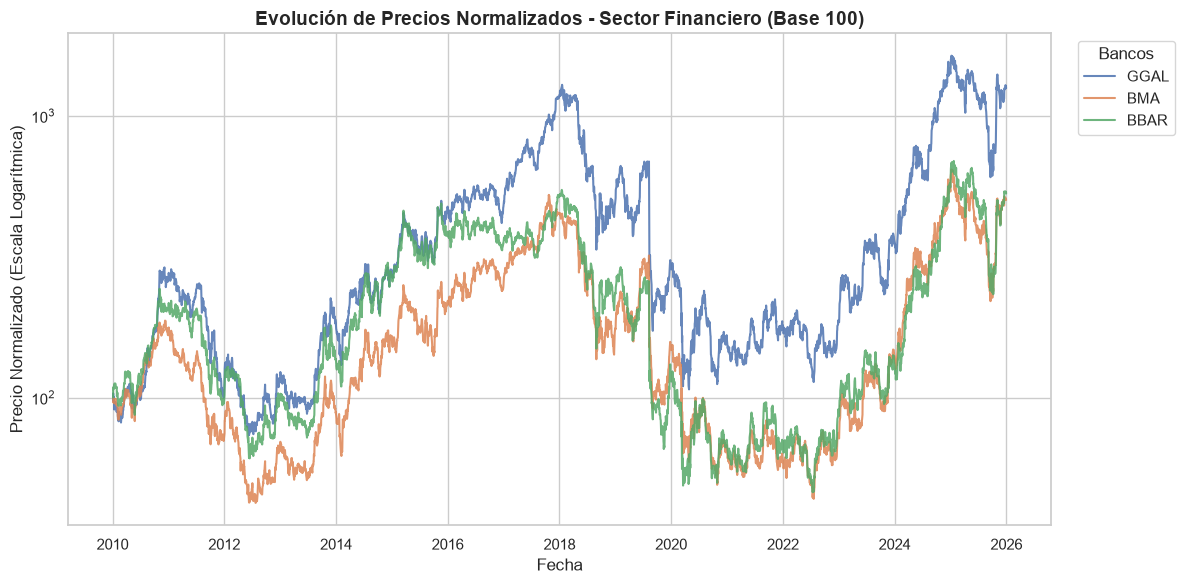

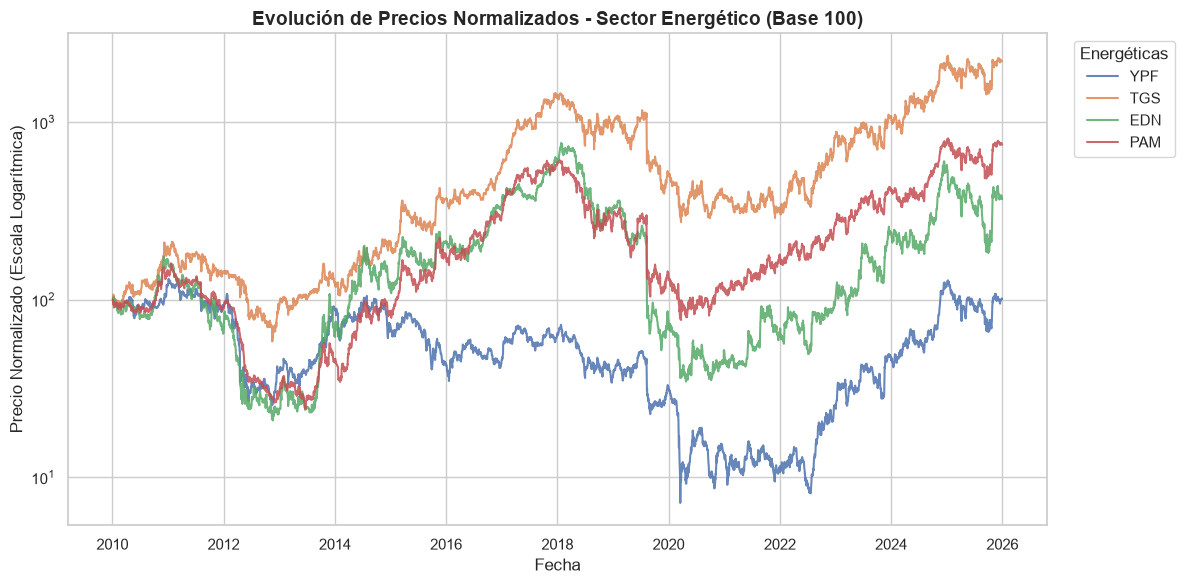

In [63]:
# 1. Normalizar precios con base 100 en la primera rueda disponible
df_norm = (df_prices / df_prices.iloc[0]) * 100

# ---------------------------------------------------------
# 2. GRÁFICO 1: SECTOR FINANCIERO (Bancos)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for col in bancos:
    plt.plot(df_norm.index, df_norm[col], label=col, alpha=0.85, linewidth=1.5)

plt.title("Evolución de Precios Normalizados - Sector Financiero (Base 100)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Precio Normalizado (Escala Logarítmica)")
plt.yscale("log")
plt.legend(title="Bancos", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. GRÁFICO 2: SECTOR ENERGÉTICO
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

for col in energia:
    plt.plot(df_norm.index, df_norm[col], label=col, alpha=0.85, linewidth=1.5)

plt.title("Evolución de Precios Normalizados - Sector Energético (Base 100)", fontsize=14, fontweight="bold")
plt.xlabel("Fecha")
plt.ylabel("Precio Normalizado (Escala Logarítmica)")
plt.yscale("log")
plt.legend(title="Energéticas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 3.1. Análisis Visual de las Series Temporal

Al observar la evolución de precios normalizados en escala logarítmica, se destacan los siguientes patrones clave para el proyecto:

* **Alta co-movilidad sectorial:** Tanto en el sector financiero como en el energético, las acciones dentro del mismo *bucket* comparten las grandes tendencias macroeconómicas argentinas (el rally 2015-2017, el colapso tras las PASO 2019, la caída por COVID-19 en 2020 y la recuperación desde 2022).
* **Comportamiento en Bancos:** Muestran una trayectoria sumamente homogénea. Galicia (`GGAL`) presenta mayor amplitud en los ciclos de alza, mientras que Banco Macro (`BMA`) y BBVA (`BBAR`) mantienen una relación de precios casi idéntica a lo largo de los 15 años.
* **Divergencias en Energía:** Aunque comparten ciclos generales, el bucket energético exhibe mayores desacoples individuales. Transportadora de Gas del Sur (`TGS`) y Pampa Energía (`PAM`) muestran una tendencia alcista de largo plazo más sólida, mientras que `YPF` sufrió caídas relativas mucho más profundas durante 2012 (expropiación) y 2020.

Esta fuerte tendencia compartida justifica la construcción de un **índice sintético sectorial**, ya que los desacoples puntuales entre una acción y su panel representan las divergencias relativas que buscaremos detectar con la transformada Wavelet de Mallat.

## 4. Retornos Diarios, Volatilidad y Matriz de Correlación

Para estudiar la dinámica diaria y preparar la base de datos para la estimación de $\beta$ y el índice sintético, calculamos los **retornos logarítmicos diarios**:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Trabajar con retornos logarítmicos garantiza aditividad temporal y simetría en las variaciones porcentuales. A continuación, calculamos la volatilidad anualizada ($\sigma_{\text{anual}} = \sigma_{\text{diaria}} \times \sqrt{252}$) y la matriz de correlación entre todos los activos del panel.

--- Volatilidad Anualizada (2010 - 2025) ---
BBAR  : 60.49%
BMA   : 57.79%
EDN   : 66.55%
GGAL  : 58.46%
PAM   : 50.72%
TGS   : 52.72%
YPF   : 52.43%


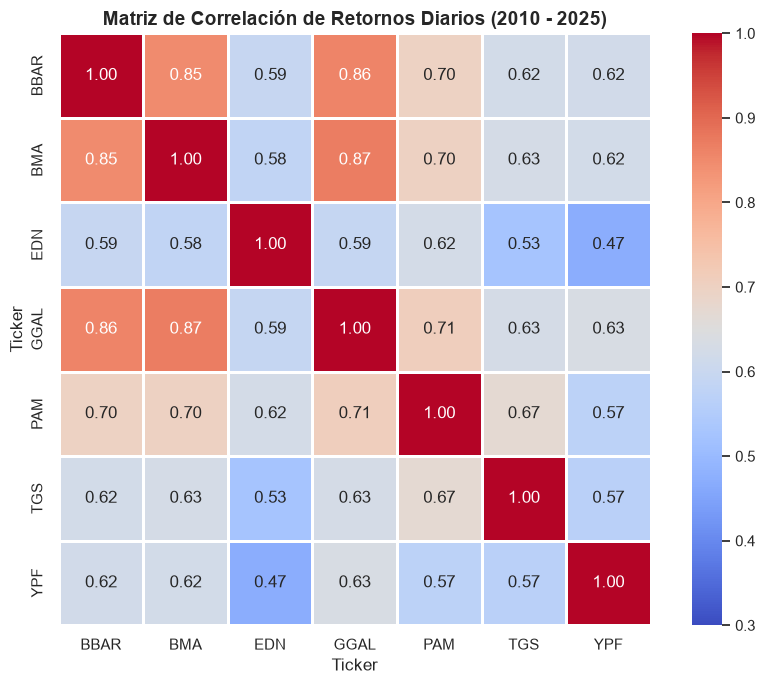

In [64]:
# 1. Cálculo de retornos logarítmicos diarios
df_returns_log = np.log(df_prices / df_prices.shift(1)).dropna()

# 2. Cálculo de Volatilidad Anualizada (asumiendo 252 ruedas por año)
volatilidad_anual = df_returns_log.std() * np.sqrt(252)

print("--- Volatilidad Anualizada (2010 - 2025) ---")
for ticker, vol in volatilidad_anual.items():
    print(f"{ticker:6s}: {vol:.2%}")

# 3. Matriz de Correlación de Retornos Diarios
corr_matrix = df_returns_log.corr()

# 4. Gráfico de la Matriz de Correlación (Mapa de Calor)
plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=0.3, 
    vmax=1.0,
    linewidths=0.8,
    square=True
)
plt.title("Matriz de Correlación de Retornos Diarios (2010 - 2025)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.1. Interpretación de la Matriz de Correlación

El mapa de calor de correlación de retornos diarios valida cuantitativamente la estructura del mercado y la elección de los dos sectores:

1. **Cluster Bancario fuertemente acoplado ($\rho \ge 0.85$):** `GGAL`, `BMA` y `BBAR` presentan una correlación altísima entre sí ($0.85$ a $0.87$). Este bloque responde de manera casi idéntica a shocks macroeconómicos, política monetaria y riesgo país.
2. **Riesgo Sistémico Argentina ($\rho \ge 0.47$):** No existe ningún par de activos con correlación baja o negativa. La cota inferior de $0.47$ (entre `YPF` y `EDN`) refleja que todos los activos comparten un factor común macroeconómico dominante.
3. **Mayor heterogeneidad en Energía:** A diferencia de los bancos, las empresas energéticas exhiben mayor variabilidad individual. Por ejemplo, `PAM` presenta una correlación más alta con el sector bancario ($\rho \approx 0.71$) por su perfil de conglomerado holding, mientras que `EDN` e `YPF` muestran mayor dinamismo propio.

Estos resultados confirman la hipótesis inicial: existe un movimiento de fondo del mercado (factor común), pero el sector energético genera descalces individuales idóneos para la búsqueda de divergencias relativas.

### 4.2. Tabla de Resumen Estadístico

Para complementar la caracterización temporal de las series, calculamos métricas estadísticas clave sobre los retornos logarítmicos de cada activo:
* **Retorno Medio Anualizado:** $\mu_{\text{anual}} = \mu_{\text{diaria}} \times 252$
* **Volatilidad Anualizada:** $\sigma_{\text{anual}} = \sigma_{\text{diaria}} \times \sqrt{252}$
* **Máxima Caída (*Max Drawdown*):** Caída máxima porcentual registrada desde un pico histórico hasta un valle local antes de recuperar un nuevo máximo.
* **Asimetría (*Skewness*) y Curtosis:** Miden la desviación respecto a una distribución normal. En series financieras con colas pesadas (*fat tails*), la curtosis elevada indica mayor probabilidad de retornos extremos (shocks de mercado).

In [65]:
# 1. Retorno medio anualizado y volatilidad
mean_return_annual = df_returns_log.mean() * 252
vol_annual = df_returns_log.std() * np.sqrt(252)

# 2. Asimetría y Curtosis de los retornos
skewness = df_returns_log.skew()
kurtosis = df_returns_log.kurtosis()

# 3. Cálculo de Max Drawdown histórico para cada activo
cumulative_returns = (1 + df_prices.pct_change().fillna(0)).cumprod()
running_max = cumulative_returns.cummax()
drawdowns = (cumulative_returns - running_max) / running_max
max_drawdown = drawdowns.min()

# 4. Consolidación en un DataFrame
df_stats = pd.DataFrame({
    "Retorno Anualizado": mean_return_annual,
    "Volatilidad Anualizada": vol_annual,
    "Max Drawdown": max_drawdown,
    "Skewness": skewness,
    "Curtosis": kurtosis
})

# Formato visual impreso para el notebook
df_stats_formatted = df_stats.copy()
df_stats_formatted["Retorno Anualizado"] = df_stats_formatted["Retorno Anualizado"].map("{:.2%}".format)
df_stats_formatted["Volatilidad Anualizada"] = df_stats_formatted["Volatilidad Anualizada"].map("{:.2%}".format)
df_stats_formatted["Max Drawdown"] = df_stats_formatted["Max Drawdown"].map("{:.2%}".format)
df_stats_formatted["Skewness"] = df_stats_formatted["Skewness"].map("{:.2f}".format)
df_stats_formatted["Curtosis"] = df_stats_formatted["Curtosis"].map("{:.2f}".format)

print("--- Resumen Estadístico (2010 - 2025) ---")
display(df_stats_formatted)

--- Resumen Estadístico (2010 - 2025) ---


,Retorno Anualizado,Volatilidad Anualizada,Max Drawdown,Skewness,Curtosis
Ticker,,,,,
BBAR,10.44%,60.49%,-91.55%,-2.23,56.44
BMA,10.12%,57.79%,-91.66%,-1.96,48.94
EDN,8.15%,66.55%,-95.48%,-1.98,54.37
GGAL,15.84%,58.46%,-91.70%,-2.65,66.83
PAM,12.58%,50.72%,-87.41%,-3.29,87.66
TGS,19.36%,52.72%,-81.27%,-1.58,41.73
YPF,0.03%,52.43%,-94.53%,-1.01,20.31


En el análisis exploratorio de datos, estas 5 métricas no son más que formas de describir la **forma, el ruido y los riesgos de la señal** que vamos a procesar


### 1. Retorno Anualizado

* **Qué es:** Es la tasa de variación del precio de la señal, proyectada a lo que subiría o bajaría en un año completo (~252 ruedas bursátiles).
* **Intuición en señales:** Indica la **tendencia de fondo (DC / componente de baja frecuencia)** de la señal. Te dice si en el largo plazo la señal tiene una deriva positiva (sube) o negativa (baja) y a qué ritmo.

### 2. Volatilidad Anualizada

* **Qué es:** Es la desviación estándar ($\sigma$) de los retornos diarios, escalada a un año multiplicando por $\sqrt{252}$.
* **Intuición en señales:** Representa la **potencia del ruido o variabilidad de alta frecuencia**.
    * Una **baja volatilidad** significa una señal suave, limpia y predecible.
    * Una **alta volatilidad** significa una señal muy "serruchada", con oscilaciones diarias violentas. Esto es clave para el proyecto porque Mallat tendrá que separar si ese ruido de alta frecuencia es solo volatilidad normal o una divergencia real respecto al mercado.



### 3. Max Drawdown (Máxima Caída Histórica)

* **Qué es:** La mayor pérdida porcentual acumulada desde el punto más alto (pico) de la serie hasta el punto más bajo (valle) antes de volver a marcar un nuevo máximo.
* **Intuición en señales:** Es la medida del **"peor escenario posible"** o amplitud de la caída máxima histórica. Te muestra la profundidad del valle más severo que sufrió la señal (por ejemplo, la caída del 80% o 90% durante la crisis de 2019 o el COVID-2020).

### 4. Skewness (Asimetría)

* **Qué es:** Mide qué tan simétrica es la distribución de los cambios diarios de la señal respecto a su promedio.
* **Intuición en señales:**
    * En una señal gaussiana ideal (campana de Gauss), la asimetría es $0$.
    * **Asimetría negativa ($< 0$):** La señal suele tener pequeñas subas continuas, pero cuando cae, pega saltos hacia abajo muy bruscos.
    * **Asimetría positiva ($> 0$):** La señal pasa mucho tiempo plana o cayendo despacio, pero de vez en cuando pega un pico alcista gigante.



### 5. Curtosis (Kurtosis)

* **Qué es:** Mide qué tan "pesadas" son las colas de la distribución de probabilidad; es decir, la frecuencia con la que ocurren eventos o picos extremos (*outliers*).
* **Intuición en señales:**
    * Una distribución Normal pura tiene una curtosis igual a $3$.
    * Si la curtosis es **mucho mayor a 3** , significa que la señal **no es gaussiana**. Tiene una gran presencia de *spikes* (picos anómalos o días de shocks extremos) que ocurren con mucha más frecuencia de lo que predeciría una distribución estadística común.


## 5. Exportación del Conjunto de Datos Procesado

Para garantizar la modularidad del proyecto y permitir que avance con la construcción de los índices sintéticos *leave-one-out* y los *spreads*, exportamos las series temporales limpias y procesadas en formato CSV dentro de la carpeta `data/`.

In [ ]:
from pathlib import Path
Path("data").mkdir(exist_ok=True)
df_prices.to_csv("data/precios_usd.csv")
df_returns_log.to_csv("data/retornos_log_usd.csv")